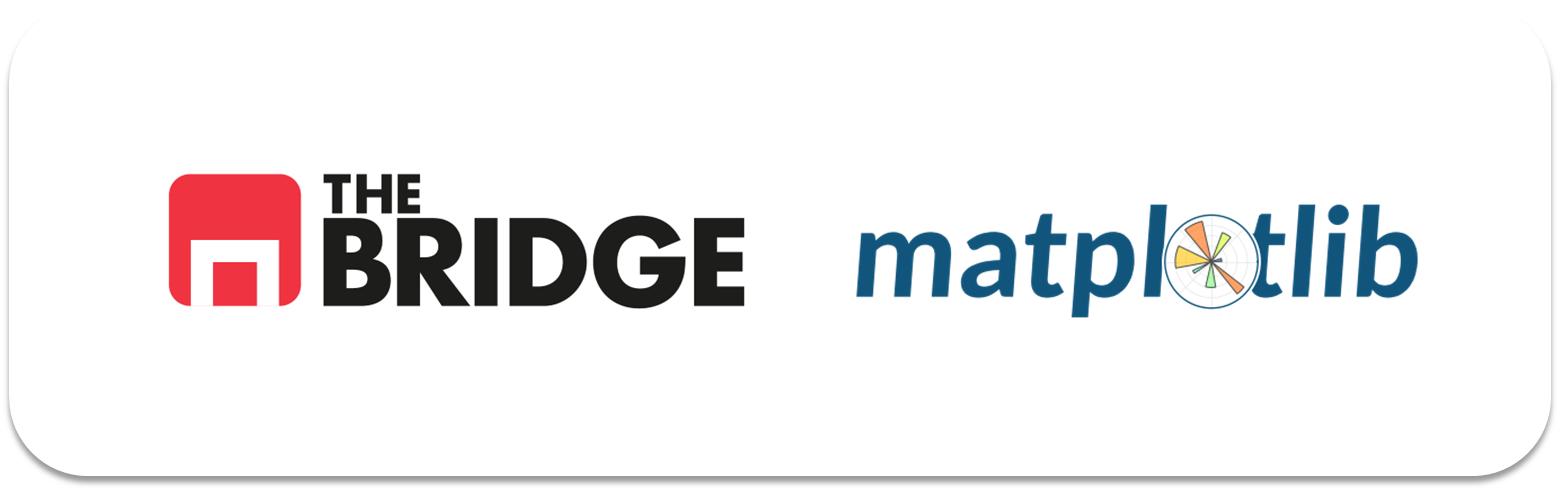

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
# Cargamos el dataset
df = pd.read_csv('./data/california_cities.csv')

In [12]:
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57


In [13]:
df.describe()

,Unnamed: 0,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
count,427.000000,427.000000,427.000000,427.000000,427.000000,4.270000e+02,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000
mean,242.018735,36.022693,-119.743048,182.416511,594.534660,6.045112e+04,17.374609,16.288689,1.092749,44.995824,42.197012,2.812687,4.877515
std,140.356018,2.298407,2.094783,311.501270,1024.317641,2.040823e+05,35.018075,32.628631,4.251690,90.671960,84.492902,11.006872,14.040821
min,0.000000,32.578333,-124.263333,-34.000000,-112.000000,1.000000e+00,0.314000,0.314000,0.000000,0.813000,0.813000,0.000000,0.000000
25%,119.500000,33.964028,-121.835278,22.000000,71.500000,1.073650e+04,3.630500,3.490500,0.000000,9.403500,9.040000,0.000000,0.000000
50%,242.000000,35.622500,-119.456389,67.000000,218.000000,2.816800e+04,8.996000,7.840000,0.029000,23.300000,20.306000,0.076000,0.320000
75%,362.500000,37.884306,-117.964167,179.500000,562.500000,6.485050e+04,19.711000,18.717500,0.210000,51.051500,48.478000,0.545000,1.860000
max,481.000000,41.965000,-114.596389,2402.000000,7880.000000,3.884307e+06,503.000000,469.000000,47.210000,1302.000000,1214.000000,122.270000,84.580000


In [5]:
df = df.dropna()

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

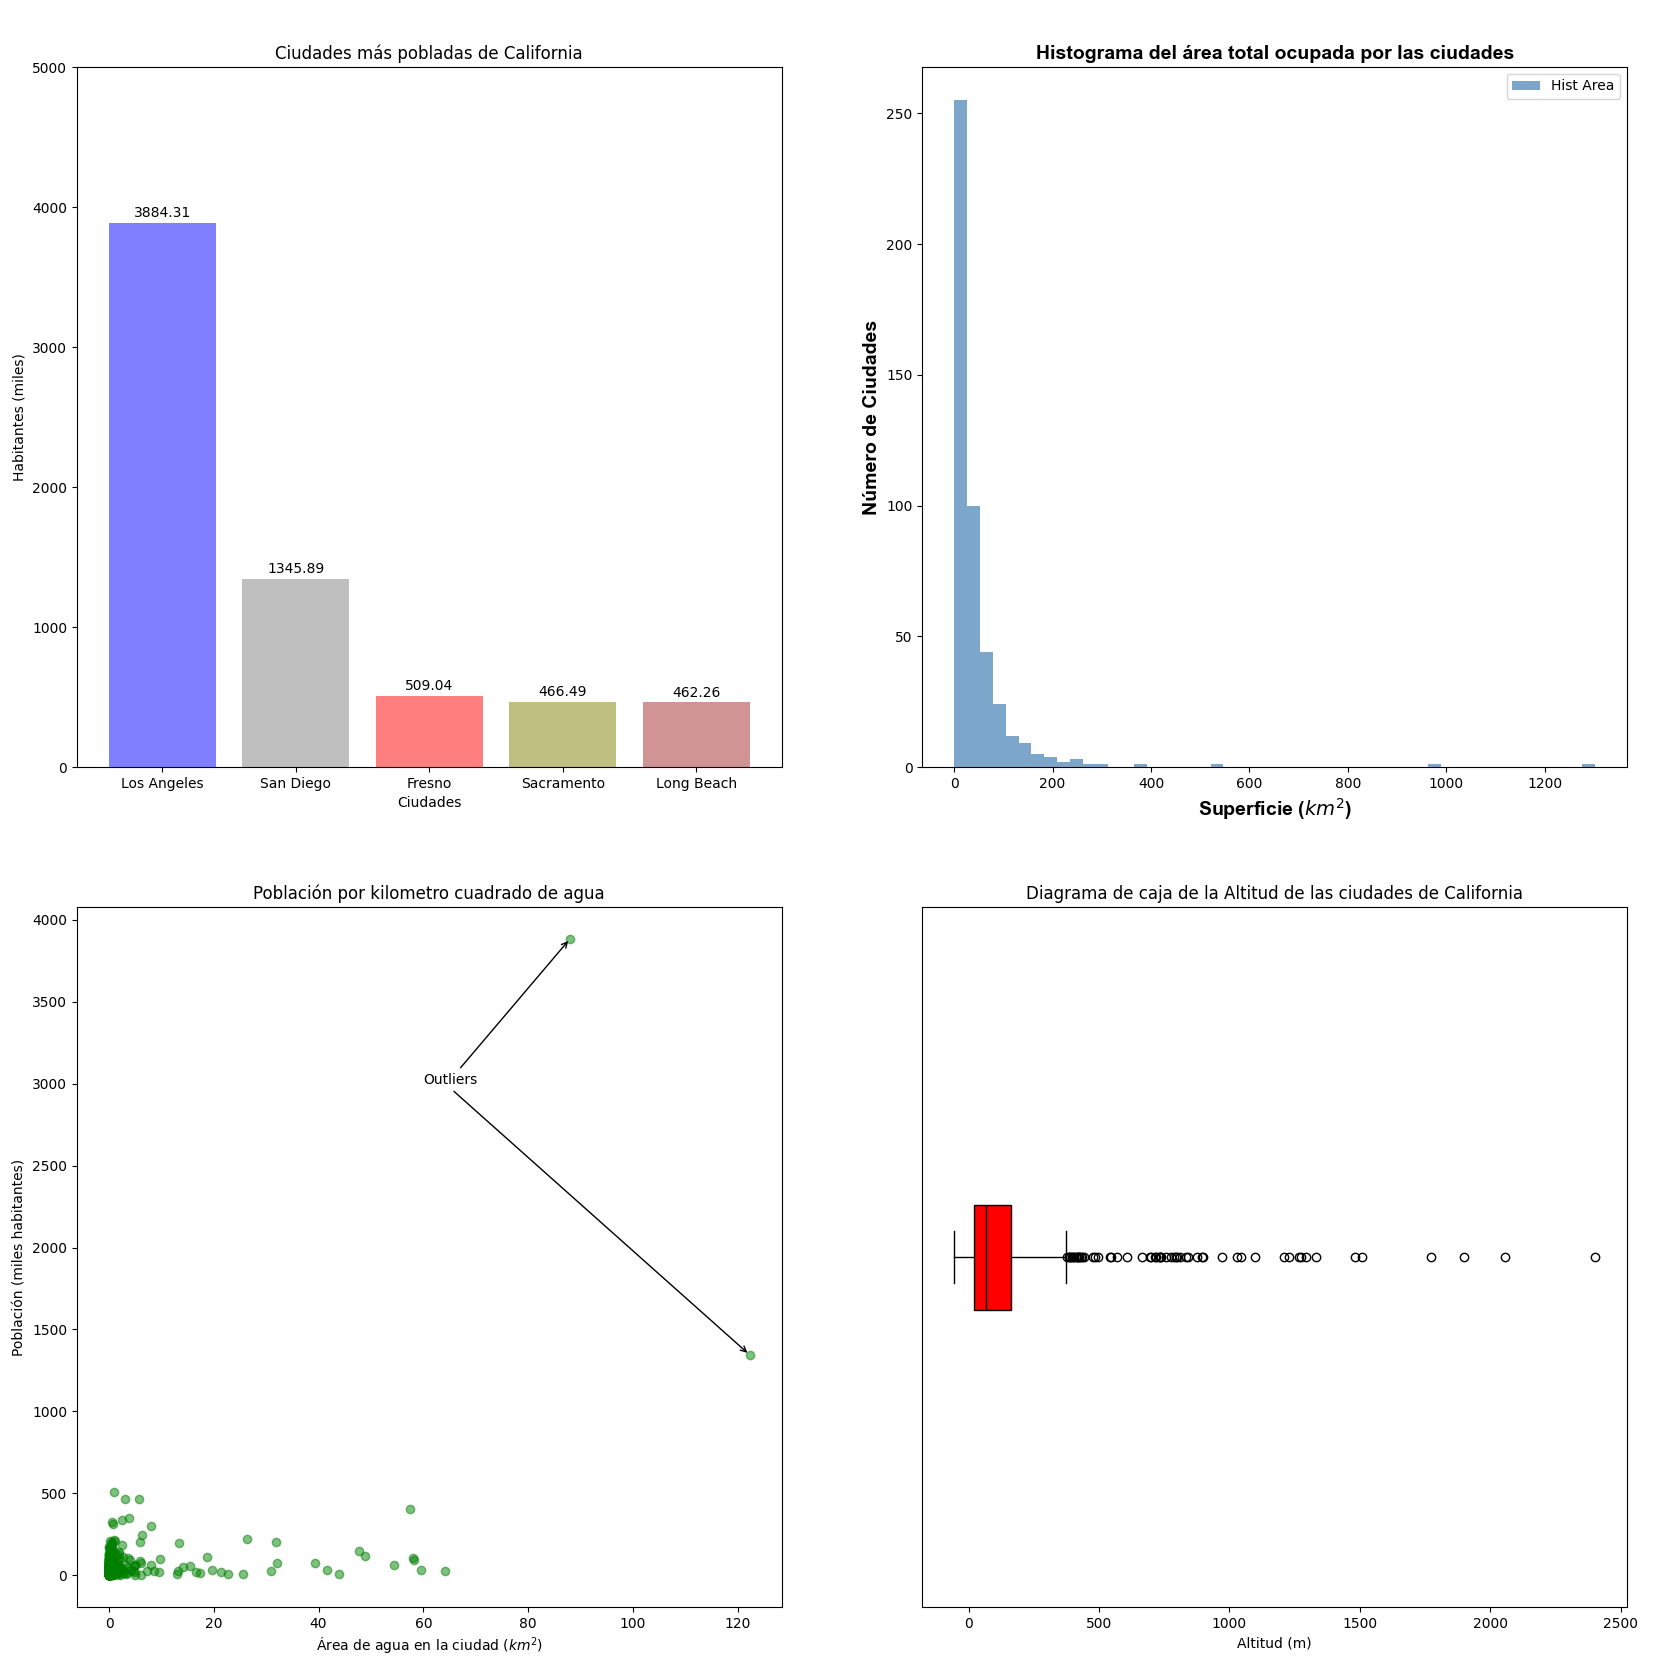

In [31]:
def separa_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo += " "
        nuevo += letra
    return nuevo

In [32]:
df_ciudades_mas_pobladas = df[["city","population_total"]].nlargest(5, columns="population_total").copy()
df_ciudades_mas_pobladas = df_ciudades_mas_pobladas.set_index("city")

ciudades = [separa_nombre(ciudad) for ciudad in df_ciudades_mas_pobladas.index]

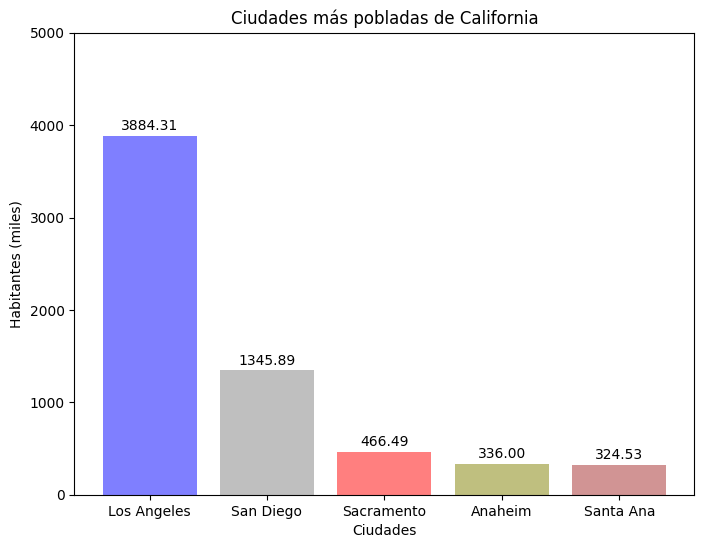

In [33]:
# ── Gráfico 1: Ciudades más pobladas ──────────────────────────────────────────
colores = ["blue","gray","red","olive","brown"]

plt.figure(figsize=(8,6))

container = plt.bar(x= ciudades, 
                    height= df_ciudades_mas_pobladas["population_total"]/1000,
                    color= colores,
                    alpha= 0.5)

plt.ylim([0,5000])
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")

plt.bar_label(container, fmt="{:.2f}", padding=2)

plt.show()

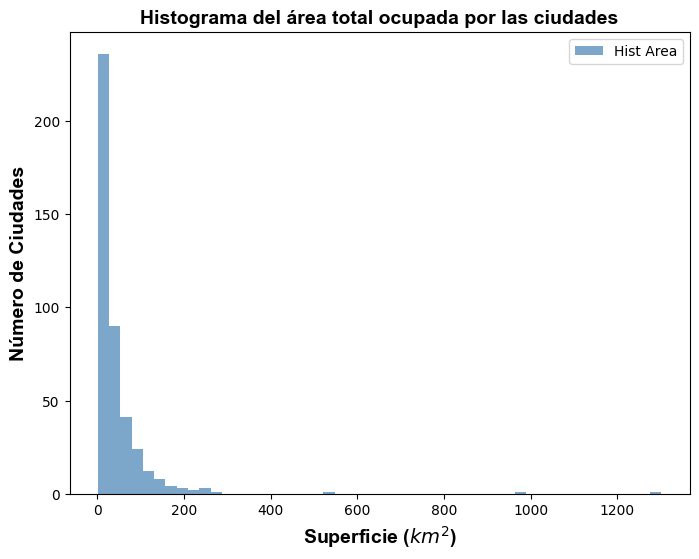

In [34]:
# ── Gráfico 2: Histograma del área total ──────────────────────────────────────
plt.figure(figsize=(8,6))


plt.hist(df["area_total_km2"],
         color= "steelblue",
         alpha= 0.7,
         bins= 50,
         label= "Hist Area")

fontdict = dict(family="Arial", size= 14, weight="bold")

plt.xlabel("Superficie ($km^2$)", fontdict= fontdict)
plt.ylabel("Número de Ciudades", fontdict= fontdict)
plt.title("Histograma del área total ocupada por las ciudades", fontdict= fontdict)
plt.legend()

plt.show()

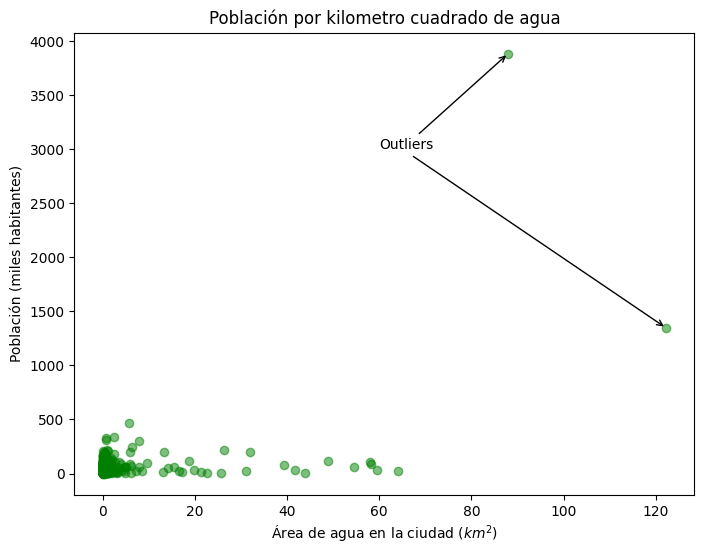

In [25]:
# ── Gráfico 3: Scatter área de agua vs población ──────────────────────────────
plt.figure(figsize=(8,6))

plt.scatter(x= df["area_water_km2"],
            y= df["population_total"]/1000,
            alpha= 0.5,
            color= "green")

plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población por kilometro cuadrado de agua")

outlier_1_y = df_ciudades_mas_pobladas["population_total"].nlargest(2).iloc[0]
outlier_2_y = df_ciudades_mas_pobladas["population_total"].nlargest(2).iloc[1]
outlier_1_x = df.loc[df["population_total"] == outlier_1_y,"area_water_km2"].values[0]
outlier_2_x = df.loc[df["population_total"] == outlier_2_y,"area_water_km2"].values[0]

text = "Outliers"
xytext=(60,3000)

plt.annotate(xy= (outlier_1_x, outlier_1_y/1000),
             xytext= xytext,
             text="Outliers",
             arrowprops= dict(arrowstyle = "->"))

plt.annotate(xy= (outlier_2_x, outlier_2_y/1000),
             xytext= xytext,
             text=" " * len(text),
             arrowprops= dict(arrowstyle = "->"))

plt.show()

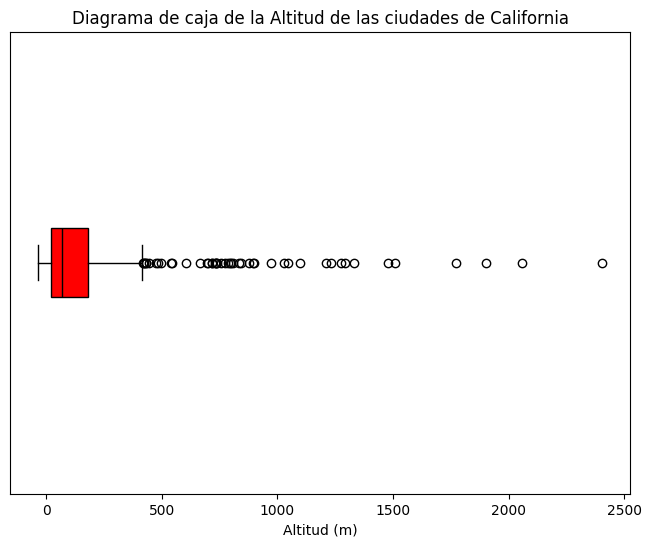

In [26]:
# ── Gráfico 4: Boxplot de la altura ───────────────────────────────────────────
plt.figure(figsize=(8,6))

plt.boxplot(df["elevation_m"],
            vert= False,
            patch_artist= True,
            boxprops = dict(facecolor = "red"),
            medianprops = dict(color= "black"))

plt.xlabel("Altitud (m)")
plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.yticks([])

plt.show()

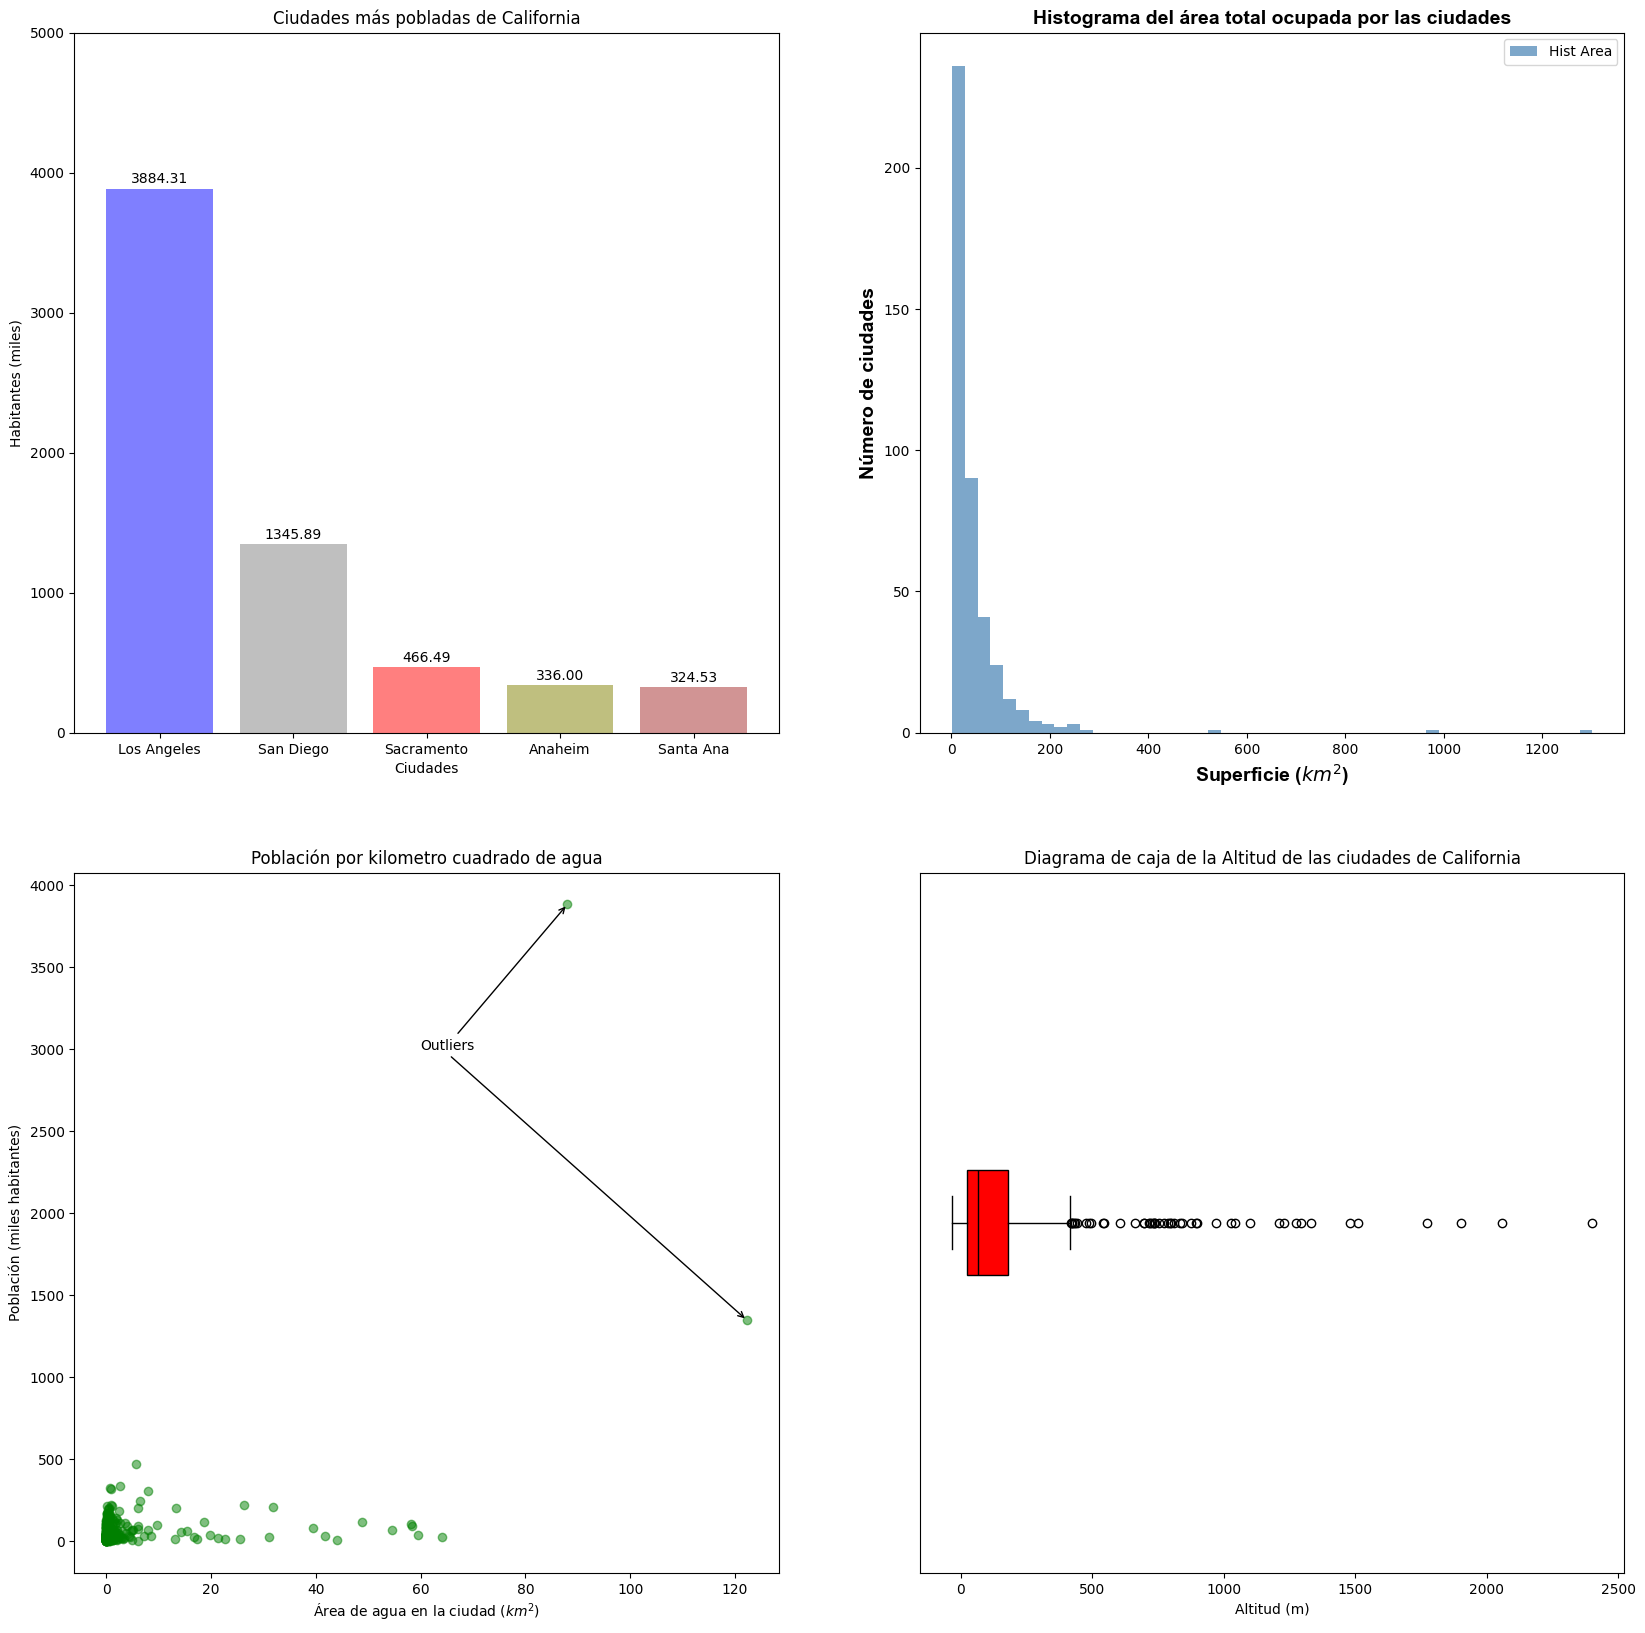

In [30]:
# ── Figura combinada con los 4 gráficos ───────────────────────────────────────
plt.figure(figsize=(20,20))

# -- 1. Barras ciudades más pobladas --
plt.subplot(2,2,1)

df_ciudades_mas_pobladas = df[["city","population_total"]].nlargest(5, columns="population_total").copy()
df_ciudades_mas_pobladas = df_ciudades_mas_pobladas.set_index("city")

ciudades = [separa_nombre(ciudad) for ciudad in df_ciudades_mas_pobladas.index]
colores = ["blue","gray","red","olive","brown"]

container = plt.bar(x= ciudades,
                    height= df_ciudades_mas_pobladas["population_total"]/1000, 
                    color = colores, 
                    alpha = 0.5)

plt.ylim([0,5000])
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")

plt.bar_label(container,
              fmt="{:.2f}",
              padding=2)

# -- 2. Histograma área total --
plt.subplot(2,2,2)

plt.hist(df["area_total_km2"],
         color = "steelblue",
         alpha = 0.7,
         bins = 50,
         label = "Hist Area")

fontdict = dict(family="Arial", size= 14, weight="bold")

plt.xlabel("Superficie ($km^2$)", fontdict = fontdict)
plt.ylabel("Número de ciudades", fontdict= fontdict)
plt.title("Histograma del área total ocupada por las ciudades", fontdict= fontdict)
plt.legend()

# -- 3. Scatter agua vs población --
plt.subplot(2,2,3)

plt.scatter(df["area_water_km2"], 
            df["population_total"]/1000, 
            alpha = 0.5, 
            color = "green")

plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población por kilometro cuadrado de agua")

outlier_1_y = df_ciudades_mas_pobladas["population_total"].nlargest(2).iloc[0]
outlier_2_y = df_ciudades_mas_pobladas["population_total"].nlargest(2).iloc[1]
outlier_1_x = df.loc[df["population_total"] == outlier_1_y,"area_water_km2"].values[0]
outlier_2_x = df.loc[df["population_total"] == outlier_2_y,"area_water_km2"].values[0]

xytext= (60,3000)
text = "Outliers"

plt.annotate(xy= (outlier_1_x,outlier_1_y/1000), 
             xytext= xytext, 
             text= text, 
             arrowprops= dict(arrowstyle = "->"))

plt.annotate(xy= (outlier_2_x,outlier_2_y/1000), 
             xytext= xytext, 
             text= " " * len(text), 
             arrowprops= dict(arrowstyle = "->"))

# -- 4. Boxplot altura --
plt.subplot(2,2,4)

plt.boxplot(df["elevation_m"],
            vert= False, 
            patch_artist= True,
            boxprops = dict(facecolor= "red"), 
            medianprops = dict(color= "black"))

plt.xlabel("Altitud (m)")
plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.yticks([])

plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [36]:
fig.savefig("practica_obligatoria.png")